# HSV a RGB

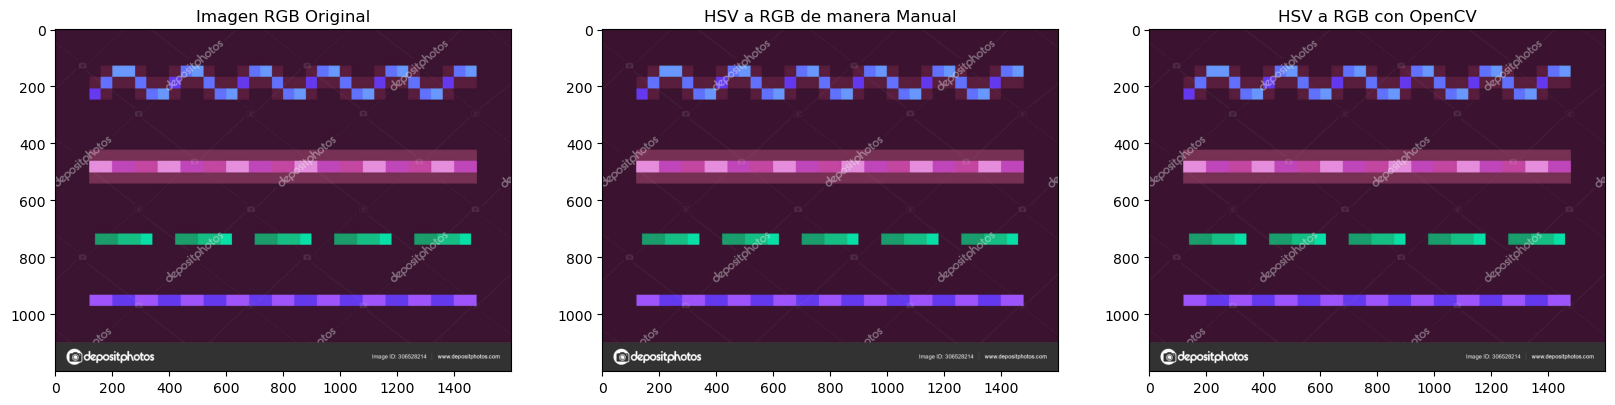

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Imagen1 = cv2.imread("imagen.jpg")
img_rgb = cv2.cvtColor(Imagen1, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

def HSV2RGB(hsv_img):
    hsv = hsv_img.astype(np.float32).copy()
    
    # Normalizar los valores
    hsv[..., 0] = hsv[..., 0] * 2 
    hsv[..., 1] = hsv[..., 1] / 255.0  
    hsv[..., 2] = hsv[..., 2] / 255.0  
    
    # Crear imagen RGB de salida
    rgb_img = np.zeros_like(hsv)
    
    H = hsv[..., 0]
    S = hsv[..., 1]
    V = hsv[..., 2]
    
    # Calcular C = V × S
    C = V * S
    
    # Calcular X = C × (1 - |(H/60) mod 2 - 1|)
    H_prime = H / 60.0
    X = C * (1 - np.abs(H_prime % 2 - 1))
    
    # Calcular m = V - C
    m = V - C
    
    # Determinar R', G', B' según el rango de H
    for i in range(hsv.shape[0]):
        for j in range(hsv.shape[1]):
            h = H[i, j]
            c = C[i, j]
            x = X[i, j]
            
            if 0 <= h < 60:
                # (C, X, 0)
                rgb_img[i, j, 0] = c
                rgb_img[i, j, 1] = x
                rgb_img[i, j, 2] = 0
            elif 60 <= h < 120:
                # (X, C, 0)
                rgb_img[i, j, 0] = x
                rgb_img[i, j, 1] = c
                rgb_img[i, j, 2] = 0
            elif 120 <= h < 180:
                # (0, C, X)
                rgb_img[i, j, 0] = 0
                rgb_img[i, j, 1] = c
                rgb_img[i, j, 2] = x
            elif 180 <= h < 240:
                # (0, X, C)
                rgb_img[i, j, 0] = 0
                rgb_img[i, j, 1] = x
                rgb_img[i, j, 2] = c
            elif 240 <= h < 300:
                # (X, 0, C)
                rgb_img[i, j, 0] = x
                rgb_img[i, j, 1] = 0
                rgb_img[i, j, 2] = c
            elif 300 <= h < 360:
                # (C, 0, X)
                rgb_img[i, j, 0] = c
                rgb_img[i, j, 1] = 0
                rgb_img[i, j, 2] = x
    
    # Sumar m y convertir a rango [0, 255]
    rgb_img[..., 0] = (rgb_img[..., 0] + m) * 255
    rgb_img[..., 1] = (rgb_img[..., 1] + m) * 255
    rgb_img[..., 2] = (rgb_img[..., 2] + m) * 255
    
    # Asegurar que los valores estén en el rango correcto
    rgb_img = np.clip(rgb_img, 0, 255).astype(np.uint8)
    
    return rgb_img

# Aplicar la conversión manual
rgb_convertida = HSV2RGB(img_hsv)

# Mostrar resultados
fig, axs = plt.subplots(1, 3, figsize=(20, 10))
axs[0].imshow(img_rgb)
axs[0].set_title('Imagen RGB Original')
axs[1].imshow(rgb_convertida)
axs[1].set_title('HSV a RGB de manera Manual')
axs[2].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
axs[2].set_title('HSV a RGB con OpenCV')
plt.show()

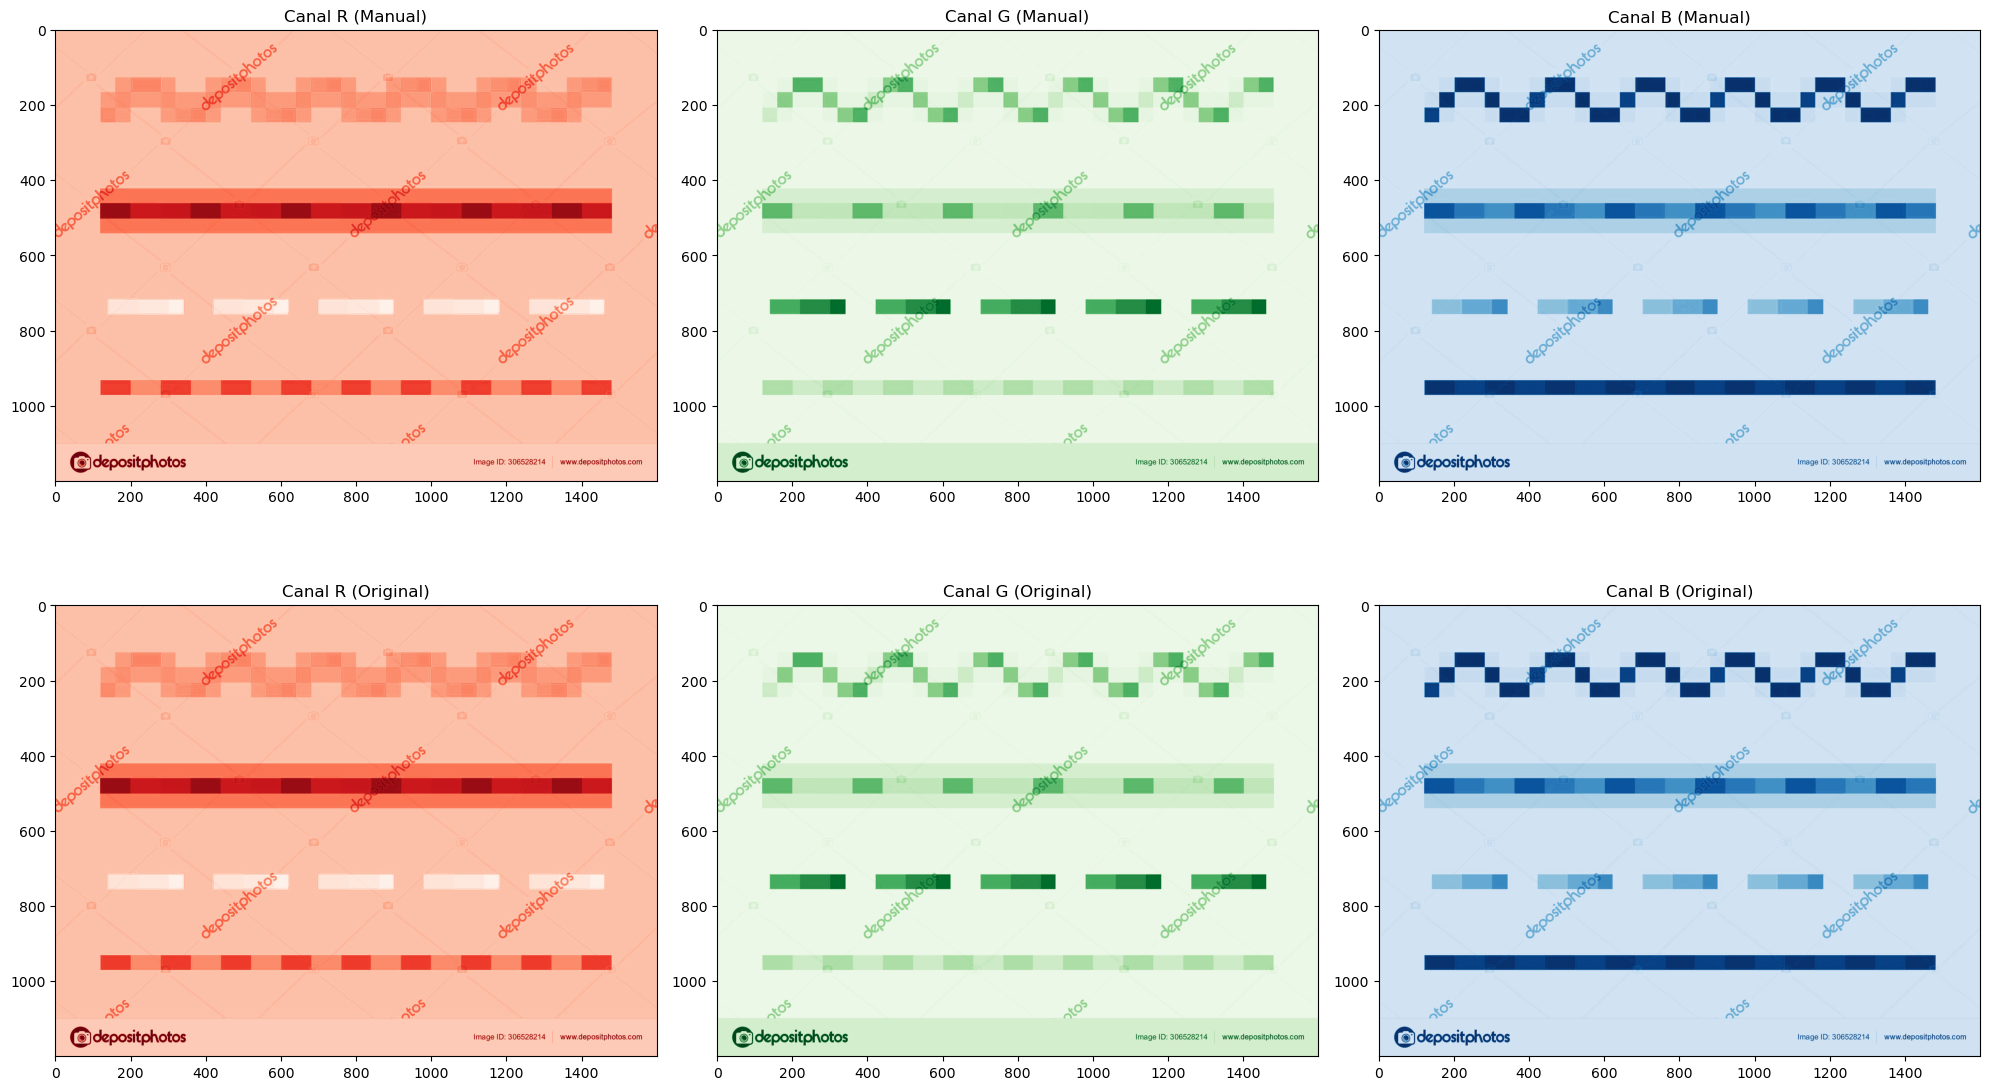

In [2]:
# Comparación de los canales
fig, axs = plt.subplots(2, 3, figsize=(20, 12))

# Canales de la conversión manual
axs[0, 0].imshow(rgb_convertida[..., 0], cmap='Reds', vmin=0, vmax=255)
axs[0, 0].set_title('Canal R de manera Manual')
axs[0, 1].imshow(rgb_convertida[..., 1], cmap='Greens', vmin=0, vmax=255)
axs[0, 1].set_title('Canal G de manera Manual')
axs[0, 2].imshow(rgb_convertida[..., 2], cmap='Blues', vmin=0, vmax=255)
axs[0, 2].set_title('Canal B de manera Manual')

# Canales de la imagen original
axs[1, 0].imshow(img_rgb[..., 0], cmap='Reds', vmin=0, vmax=255)
axs[1, 0].set_title('Canal R de la Original')
axs[1, 1].imshow(img_rgb[..., 1], cmap='Greens', vmin=0, vmax=255)
axs[1, 1].set_title('Canal G de la Original')
axs[1, 2].imshow(img_rgb[..., 2], cmap='Blues', vmin=0, vmax=255)
axs[1, 2].set_title('Canal B de la Original')

plt.tight_layout()
plt.show()